<a href="https://colab.research.google.com/github/228w1a1281/Python-Applications-and-Data-Manipulation/blob/main/DS_Intern_Month_2_Task_3_%26_4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# DATA SCIENCE INTERNSHIP  MONTH - 2



**TASK 3: Customer Churn Data Preparation & EDA**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 1: Load Dataset

In [3]:
# Install dependencies
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# File path
file_path = "WA_Fn-UseC_-Telco-Customer-Churn.csv"

# Load dataset
df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "blastchar/telco-customer-churn",
    file_path
)

print("First 5 records:")
print(df.head())

/tmp/ipykernel_9922/4041642709.py:15: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'telco-customer-churn' dataset.
First 5 records:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  7590-VHVEG  Female              0     Yes         No       1           No   
1  5575-GNVDE    Male              0      No         No      34          Yes   
2  3668-QPYBK    Male              0      No         No       2          Yes   
3  7795-CFOCW    Male              0      No         No      45           No   
4  9237-HQITU  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity  ... DeviceProtection  \
0  No phone service             DSL             No  ...               No   
1                No             DSL            Yes  ...              Yes   
2                No             DSL            Yes  ...               No   
3  No phone service             DSL            Yes  ...              Yes   
4                No     Fiber optic            

Step 2: Data Understanding

In [4]:
print(df.shape)
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())

(7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null

Step 3: Identify Strange Values

In [5]:
(df == " ").sum()

,0
customerID,0
gender,0
SeniorCitizen,0
Partner,0
Dependents,0
tenure,0
PhoneService,0
MultipleLines,0
InternetService,0
OnlineSecurity,0


Step 4: Data Cleaning

1.Convert TotalCharges to numeric

In [6]:
df['TotalCharges'] = df['TotalCharges'].replace(" ", np.nan)
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'])

2.Fill missing values

In [7]:
df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)

/tmp/ipykernel_9922/2840544469.py:1: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


3.Drop customerID

In [8]:
df.drop('customerID', axis=1, inplace=True)

Step 5: Feature Engineering

1.Tenure Group

In [9]:
bins = [0,12,24,36,48,60,72]
labels = ['0-12','13-24','25-36','37-48','49-60','61-72']

df['TenureGroup'] = pd.cut(df['tenure'], bins=bins, labels=labels)

2.Average Monthly Spend

In [10]:
df['AvgMonthlySpend'] = df['TotalCharges'] / (df['tenure'] + 1)

3.Binary Conversion

In [11]:
binary_cols = ['Partner','Dependents','PhoneService','PaperlessBilling','Churn']

for col in binary_cols:
    df[col] = df[col].map({'Yes':1,'No':0})

Step 6: One-Hot Encoding

In [12]:
df = pd.get_dummies(df, columns=['Contract','InternetService'], drop_first=True)

Step 7: EDA Visualizations

1.:Churn Distribution

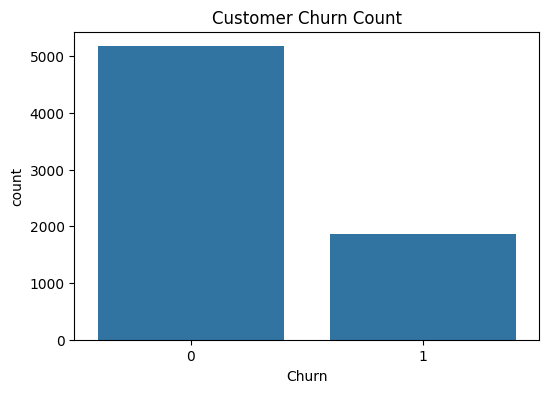

In [13]:
plt.figure(figsize=(6,4))
sns.countplot(x='Churn', data=df)
plt.title("Customer Churn Count")
plt.show()

2.Contract vs Churn

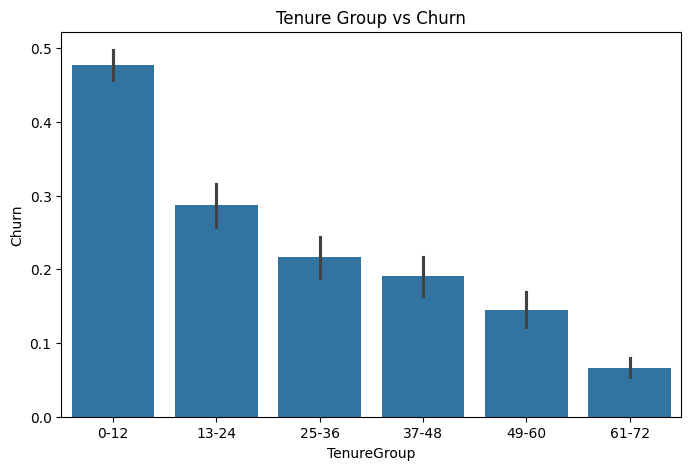

In [14]:
plt.figure(figsize=(8,5))
sns.barplot(x='TenureGroup', y='Churn', data=df)
plt.title("Tenure Group vs Churn")
plt.show()

3.Heatmap

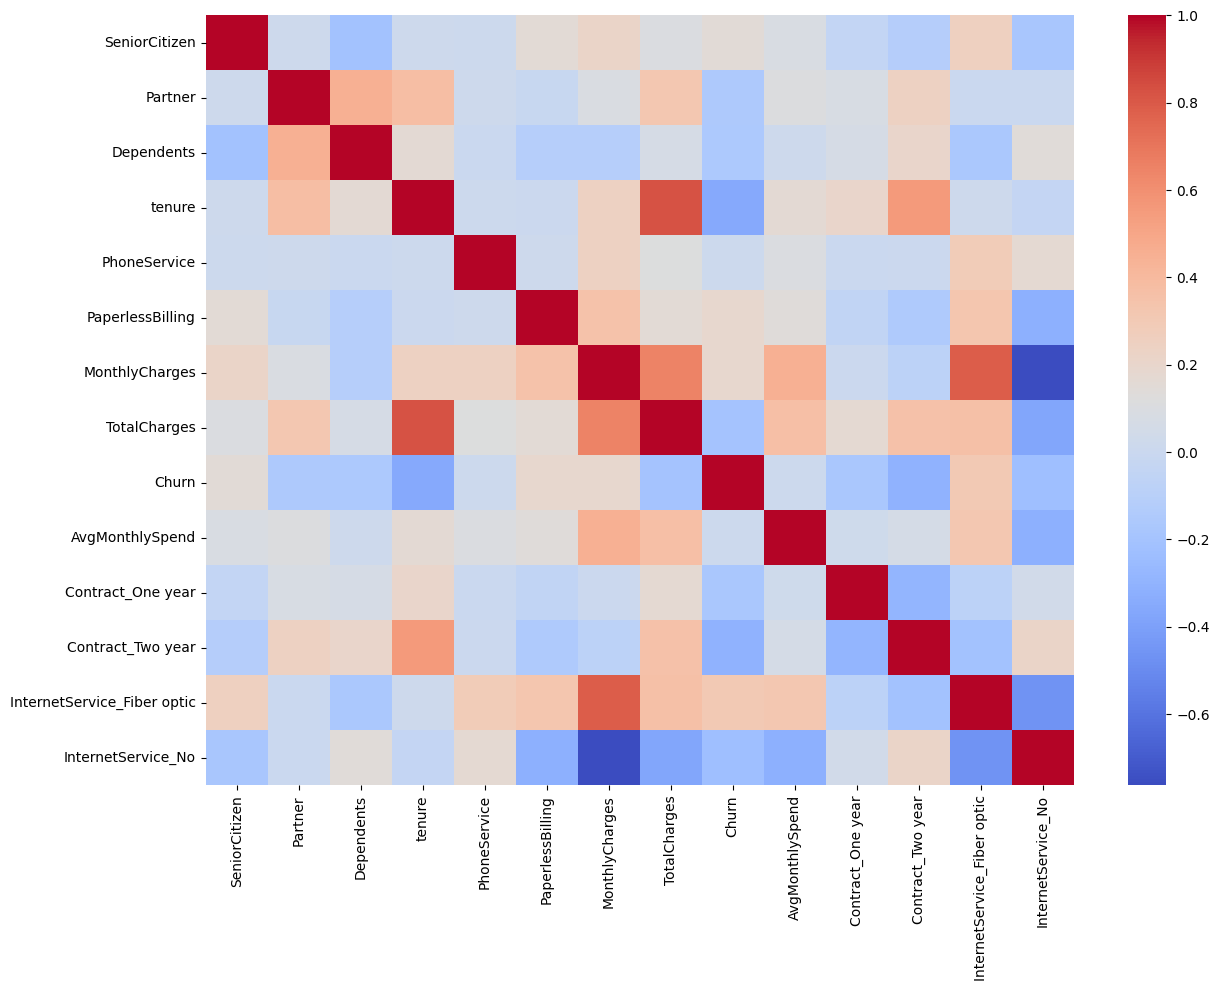

In [15]:
plt.figure(figsize=(14,10))
sns.heatmap(df.corr(numeric_only=True), cmap='coolwarm')
plt.show()

4.Monthly Charges by Churn

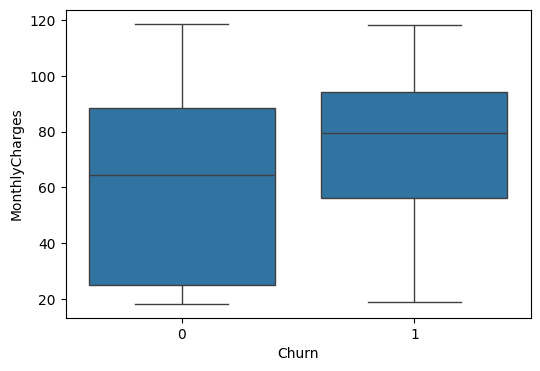

In [16]:
plt.figure(figsize=(6,4))
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

Step 8: Save Cleaned File

In [17]:
df.to_csv("cleaned_telco_churn.csv", index=False)

**TASK 4: Netflix Titles Dataset – Exploratory Analysis & Insights**

Step 1: Install & Import

In [18]:
!pip install kagglehub[pandas-datasets]

import kagglehub
from kagglehub import KaggleDatasetAdapter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Step 2: Load Dataset

In [19]:
file_path = "netflix_titles.csv"

df = kagglehub.load_dataset(
    KaggleDatasetAdapter.PANDAS,
    "shivamb/netflix-shows",
    file_path
)

print(df.head())

/tmp/ipykernel_9922/434019720.py:3: DeprecationWarning: Use dataset_load() instead of load_dataset(). load_dataset() will be removed in a future version.
  df = kagglehub.load_dataset(


Using Colab cache for faster access to the 'netflix-shows' dataset.
  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2

Step 3: Data Understanding

In [20]:
print(df.shape)
print(df.info())
print(df.describe(include='all'))
print(df.isnull().sum())

(8807, 12)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None
       show_id   type   title       director                cast  \
count     8807   8807    8807           6173                7982   
unique    8807      2    8807           4528                7692   
top      s8807  Movie  Zubaan  R

Step 4: Data Cleaning

1.Convert date_added to datetime

In [21]:
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

2.Fill missing values

In [22]:
df['director'] = df['director'].fillna('Unknown')
df['cast'] = df['cast'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown')
df['rating'] = df['rating'].fillna('Not Rated')

Step 5: Feature Engineering

1.Release decade

In [23]:
df['release_decade'] = (df['release_year'] // 10) * 10

2.Movie / TV Show indicator

In [24]:
df['is_movie'] = df['type'].apply(lambda x: 1 if x == 'Movie' else 0)

3.Year added

In [25]:
df['year_added'] = df['date_added'].dt.year

4.Content type column

In [26]:
df['content_type'] = df['type']

Step 6: Top 5 Countries

In [27]:
top_countries = df['country'].str.split(', ').explode().value_counts().head(5)
print(top_countries)

country
United States     3689
India             1046
Unknown            831
United Kingdom     804
Canada             445
Name: count, dtype: int64


Step 7: Visualizations
1.Pie Chart — Movies vs TV Shows

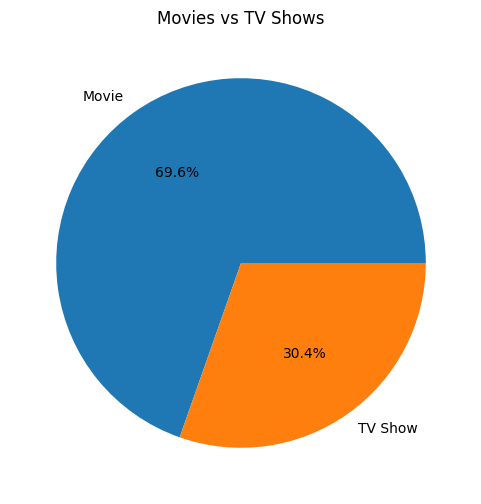

In [28]:
df['type'].value_counts().plot.pie(autopct='%1.1f%%', figsize=(6,6))
plt.title("Movies vs TV Shows")
plt.ylabel('')
plt.show()

2.Line Plot — Content Released Per Year

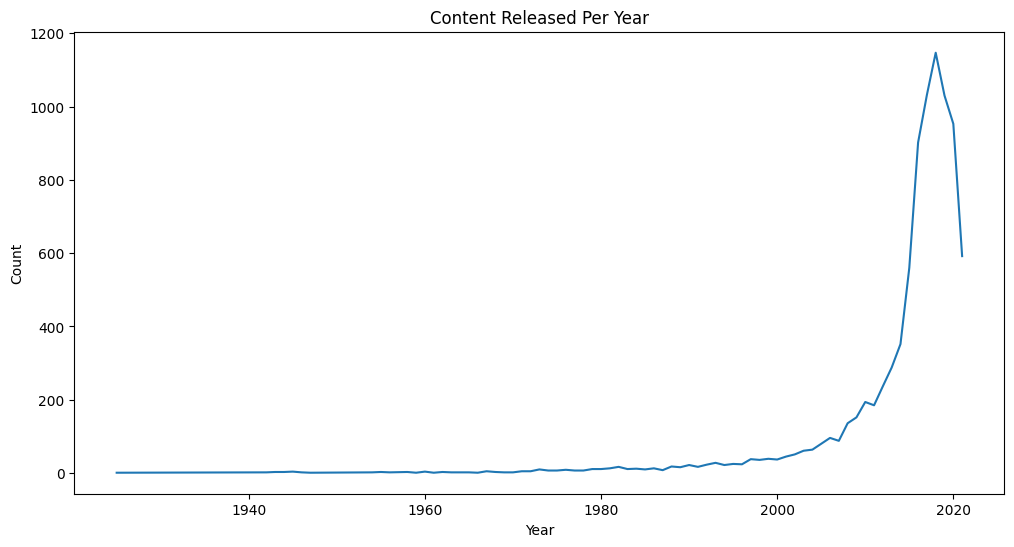

In [29]:
year_counts = df['release_year'].value_counts().sort_index()

plt.figure(figsize=(12,6))
year_counts.plot()
plt.title("Content Released Per Year")
plt.xlabel("Year")
plt.ylabel("Count")
plt.show()

3.Barplot — Top 10 Genres

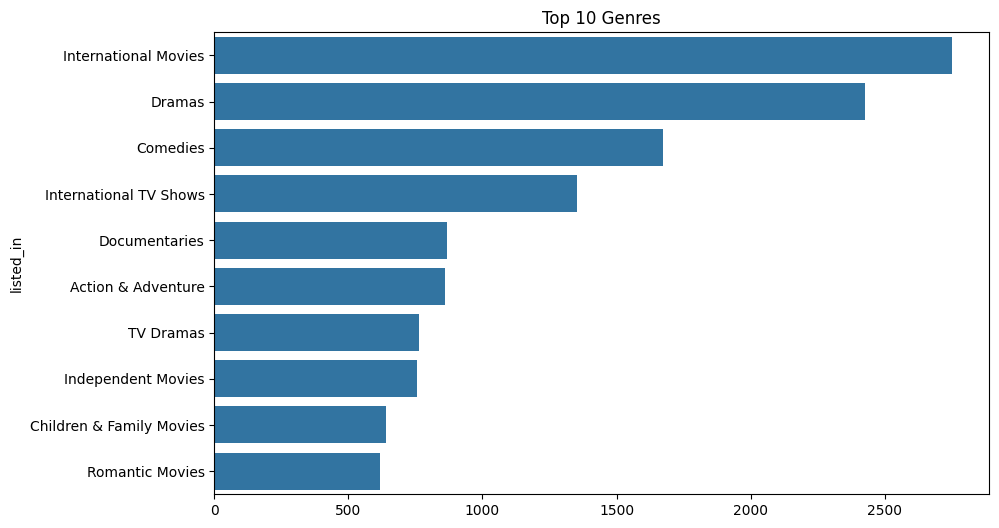

In [30]:
genres = df['listed_in'].str.split(', ').explode()
top_genres = genres.value_counts().head(10)

plt.figure(figsize=(10,6))
sns.barplot(x=top_genres.values, y=top_genres.index)
plt.title("Top 10 Genres")
plt.show()

4.Heatmap — Country vs Content Volume

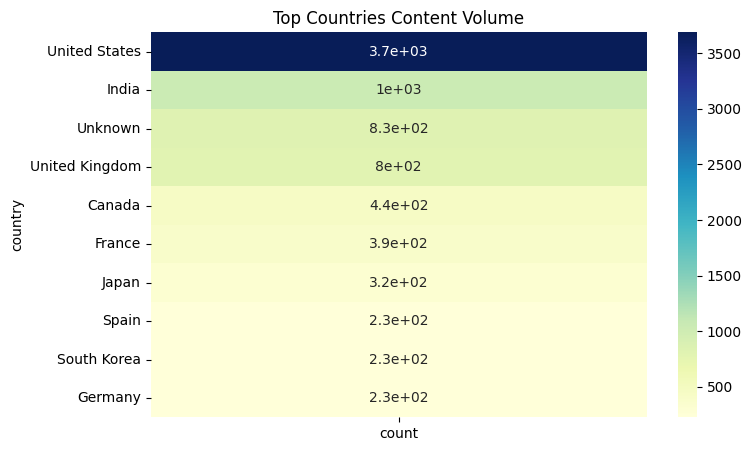

In [31]:
country_counts = df['country'].str.split(', ').explode().value_counts().head(10)

plt.figure(figsize=(8,5))
sns.heatmap(country_counts.to_frame(), annot=True, cmap='YlGnBu')
plt.title("Top Countries Content Volume")
plt.show()

5.Release Decade Distribution

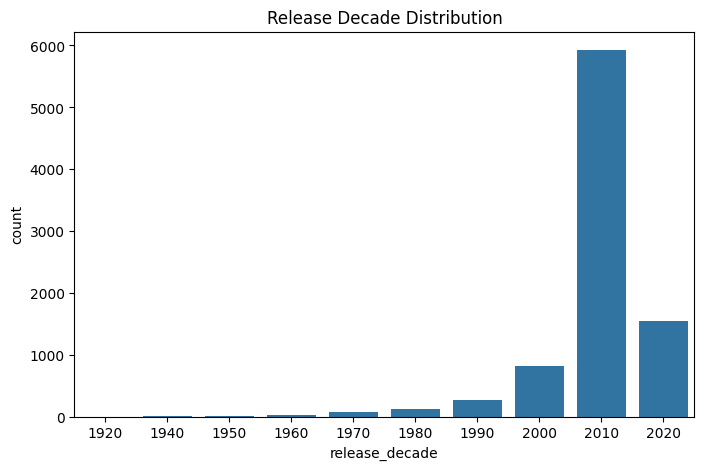

In [32]:
plt.figure(figsize=(8,5))
sns.countplot(x='release_decade', data=df)
plt.title("Release Decade Distribution")
plt.show()

Step 8: Save Cleaned Dataset

In [33]:
df.to_csv("cleaned_netflix_titles.csv", index=False)

Predict Next 2 Years Trend

In [35]:
from sklearn.linear_model import LinearRegression
import numpy as np

year_df = year_counts.reset_index()
year_df.columns = ['Year', 'Count']

X = year_df[['Year']]
y = year_df['Count']

model = LinearRegression()
model.fit(X, y)

future_years = pd.DataFrame({'Year':[2022, 2023]})
pred = model.predict(future_years)

print(pred)

[383.48100366 390.36478638]
